<img src="imagens/yochi.png" width="100%">

<h1 style="font-size: 56px; font-weight: 900; letter-spacing: 0px; margin: 0;"><span style="color: #f66001;">YOCHI COMPANY:</span> MODELO DE RISCO DE CRÉDITO</h1>
<br>

Modelo de previsão de default de crédito imobiliário desenvolvido sobre a base do caso YOCHI (5.960 clientes, 12 variáveis geográficas, demográficas e financeiras). O trabalho cobre o pipeline completo: tratamento de valores faltantes por categoria e regra de negócio, seleção de variáveis por Information Value, segmentação de risco por árvore de decisão e construção de um scorecard com regressão logística (StandardScaler e One-Hot Encoding, AUC de 0,78). A partir do score de risco define-se um ponto de corte que equilibra volume de aprovação e inadimplência, traduzido em resultado financeiro com premissas de perda por default e custo de oportunidade (CDI). A solução reduz a perda estimada da carteira de 20,1 para cerca de 10 milhões de reais.

<div style="background:#fff7f7;padding:6px 26px;margin:18px 0;">
<p style="font-weight:800;margin-bottom:4px;">ROTEIRO</p>
<ol style="color:#2D2A32;line-height:1.7;">
<li>Problema de negócio</li>
<li>Importando bibliotecas</li>
<li>Conjunto de dados</li>
<li>Análise exploratória</li>
<li>Qualidade dos dados e valores ausentes</li>
<li>Partição treino / teste</li>
<li>Weight of Evidence e Information Value</li>
<li>Pré-processamento como pipeline</li>
<li>Modelagem: baseline logístico e challenger XGBoost</li>
<li>Avaliação: ROC, KS, Gini, matriz de confusão e escolha de corte</li>
<li>Interpretação e scorecard (PDO)</li>
<li>Conclusão</li>
</ol></div>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# Paleta igual à do deck: 0 = adimplente (vermelho), 1 = default (teal)
COR_ADIMPL  = '#F8766D'
COR_DEFAULT = '#00BFC4'
AZUL        = '#1F3864'

In [12]:
df = pd.read_excel('data/yochi_base.xlsx')
print('Dimensões:', df.shape)
df.head()

Dimensões: (5960, 13)


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">1. SITUAÇÃO ATUAL</h1>
<p style="font-size:15px;line-height:1.6;color:#2D2A32;">

In [13]:
resumo = (df['BAD'].value_counts()
                   .rename_axis('BAD')
                   .reset_index(name='QTD')
                   .sort_values('BAD'))
resumo['PERC'] = (resumo['QTD'] / resumo['QTD'].sum() * 100).round(2)

total = pd.DataFrame({'BAD': ['Total'],
                      'QTD': [resumo['QTD'].sum()],
                      'PERC': [100.00]})
tabela = pd.concat([resumo, total], ignore_index=True)

(tabela.style
   .format({'QTD': '{:,.0f}', 'PERC': '{:.2f}%'})
   .hide(axis='index')
   .set_caption('Distribuição do target BAD'))

BAD,QTD,PERC
0,"4,771",80.05%
1,"1,189",19.95%
Total,"5,960",100.00%


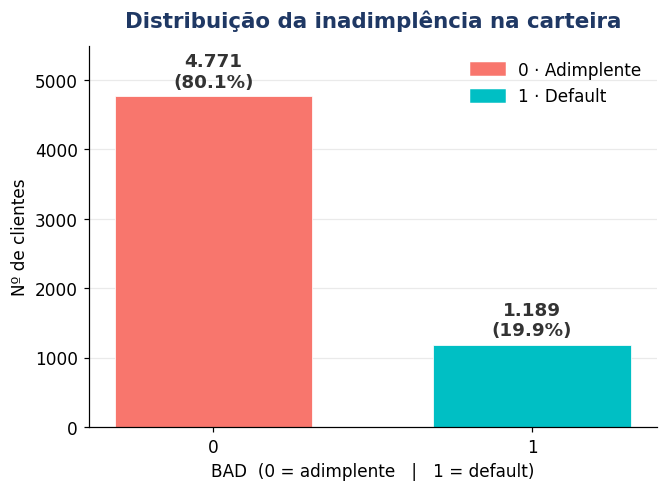

In [14]:
cont = df['BAD'].value_counts().sort_index()
n0, n1 = int(cont[0]), int(cont[1])
tot = n0 + n1
p0, p1 = n0 / tot * 100, n1 / tot * 100

fig, ax = plt.subplots(figsize=(6.2, 4.6))
barras = ax.bar(['0', '1'], [n0, n1],
                color=[COR_ADIMPL, COR_DEFAULT],
                width=0.62, edgecolor='white', linewidth=0.5)

rotulos = [f'{n0:,}\n({p0:.1f}%)'.replace(',', '.'),
           f'{n1:,}\n({p1:.1f}%)'.replace(',', '.')]
for b, r in zip(barras, rotulos):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 70, r,
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333')

ax.set_title('Distribuição da inadimplência na carteira',
             fontsize=14, fontweight='bold', color=AZUL, pad=12)
ax.set_ylabel('Nº de clientes')
ax.set_xlabel('BAD  (0 = adimplente   |   1 = default)')
ax.set_ylim(0, n0 * 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#EAEAEA', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(handles=[Patch(color=COR_ADIMPL,  label='0 · Adimplente'),
                   Patch(color=COR_DEFAULT, label='1 · Default')],
          loc='upper right', frameon=False)

plt.tight_layout()
# plt.savefig('yochi_situacao_barras.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

A carteira tem 5.960 clientes e 19,95% deles (1.189) entraram em default.

Esses inadimplentes concentram R$ 20,1 MM de crédito concedido, cerca de 18% de todo o montante emprestado.

A aprovação de crédito é feita sem embasamento estatístico, o que permite liberar recursos para perfis de alto risco e sustenta a perda observada.

Reduzir esse prejuízo exige identificar os perfis de maior risco e apoiar a decisão de aprovação em um modelo preditivo.

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">2. TRATAMENTO DE DADOS</h1>
<p style="font-size:15px;line-height:1.6;color:#2D2A32;">

In [15]:
df.isna().sum()

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

In [18]:
df_t = df.copy()

# YOJ faltante: 0 se JOB também estava vazio, senão 1 (usa a ausência ORIGINAL de JOB)
job_missing = df_t['JOB'].isna()
yoj_missing = df_t['YOJ'].isna()
df_t.loc[yoj_missing & job_missing,  'YOJ'] = 0
df_t.loc[yoj_missing & ~job_missing, 'YOJ'] = 1

# REASON e JOB faltantes -> nova categoria "Missing"
df_t['REASON'] = df_t['REASON'].fillna('Missing')
df_t['JOB']    = df_t['JOB'].fillna('Missing')

# DELINQ, DEROG, NINQ, CLNO, DEBTINC faltantes -> 0
for c in ['DELINQ', 'DEROG', 'NINQ', 'CLNO', 'DEBTINC']:
    df_t[c] = df_t[c].fillna(0)

for c in ['MORTDUE', 'VALUE', 'CLAGE']:
    df_t[c] = df_t[c].fillna(df_t[c].median())

In [20]:
def information_value(serie, y, bins=10):
    s = serie.copy()
    # numérica com muitos valores -> faixas por decis; caso contrário, categorias
    if s.dtype.kind in 'biufc' and s.nunique() > 12:
        grupo = pd.qcut(s, bins, duplicates='drop')
    else:
        grupo = s.astype(str)

    d = pd.DataFrame({'grupo': grupo, 'y': y})
    t = d.groupby('grupo', observed=True)['y'].agg(['count', 'sum'])
    t.columns = ['tot', 'bad']
    t['good'] = t['tot'] - t['bad']

    B, G = t['bad'].sum(), t['good'].sum()
    t['dist_bad']  = (t['bad']  / B).replace(0, 0.5 / B)
    t['dist_good'] = (t['good'] / G).replace(0, 0.5 / G)
    t['woe'] = np.log(t['dist_good'] / t['dist_bad'])
    return ((t['dist_good'] - t['dist_bad']) * t['woe']).sum()

In [21]:
y = df_t['BAD']
ivs = {c: information_value(df_t[c], y) for c in df_t.columns if c != 'BAD'}

def faixa_iv(iv):
    if iv < 0.02:  return 'sem poder'
    if iv < 0.10:  return 'fraco'
    if iv < 0.30:  return 'médio'
    if iv < 0.50:  return 'forte'
    return 'muito forte'

ranking = (pd.Series(ivs, name='IV')
             .sort_values(ascending=False)
             .rename_axis('Variável')
             .reset_index())
ranking['Poder preditivo'] = ranking['IV'].apply(faixa_iv)

ranking.style.format({'IV': '{:.3f}'}).hide(axis='index')

Variável,IV,Poder preditivo
DEBTINC,1.328,muito forte
DELINQ,0.411,forte
DEROG,0.411,forte
CLAGE,0.232,médio
VALUE,0.165,médio
NINQ,0.164,médio
LOAN,0.160,médio
JOB,0.124,médio
CLNO,0.069,fraco
MORTDUE,0.053,fraco


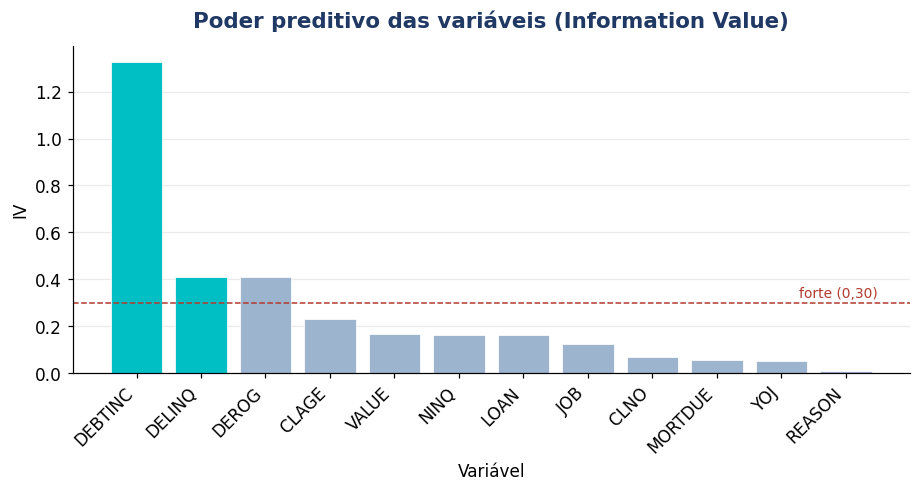

In [22]:
top_n = 2  
cores = [COR_DEFAULT if i < top_n else '#9DB4CE' for i in range(len(ranking))]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(ranking['Variável'], ranking['IV'], color=cores,
       edgecolor='white', linewidth=0.5)

ax.set_title('Poder preditivo das variáveis (Information Value)',
             fontsize=14, fontweight='bold', color=AZUL, pad=12)
ax.set_ylabel('IV')
ax.set_xlabel('Variável')
ax.axhline(0.30, color='#B03A2E', ls='--', lw=1)   # limiar "forte"
ax.text(len(ranking) - 0.5, 0.31, 'forte (0,30)', color='#B03A2E',
        ha='right', va='bottom', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#EAEAEA', linewidth=0.8)
ax.set_axisbelow(True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('yochi_iv_ranking.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

As variáveis mais preditivas de default são DEBTINC (relação dívida/receita) e DELINQ (linhas de crédito inadimplentes), seguidas de DEROG (relatórios depreciativos).

O risco está concentrado em endividamento e histórico de atraso. Isso indica dois problemas no processo atual, escolha de clientes com perfil arriscado e aprovação de clientes que já chegam com linhas em atraso.

Variáveis como REASON, YOJ e MORTDUE têm baixo poder preditivo e pouco contribuem para separar bons e maus pagadores.

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">3. SEGMENTAÇÃO POR PERFIL</h1>
<p style="font-size:15px;line-height:1.6;color:#2D2A32;">

In [23]:
bins   = [-np.inf, 1, 2, np.inf]
labels = ['< 1  (ou Missing)', '1 a < 2', '>= 2']
df_t['grupo_delinq'] = pd.cut(df_t['DELINQ'], bins=bins, labels=labels, right=False)

seg = df_t.groupby('grupo_delinq', observed=True)['BAD'].agg(
        Count='count', defaults='sum', tx_default='mean')
seg['tx_default'] = (seg['tx_default'] * 100).round(2)
seg['%_pop']      = (seg['Count'] / seg['Count'].sum() * 100).round(1)
seg = seg.reset_index()

seg.style.format({'tx_default': '{:.2f}%', '%_pop': '{:.1f}%'}).hide(axis='index')

grupo_delinq,Count,defaults,tx_default,%_pop
< 1 (ou Missing),4759,655,13.76%,79.8%
1 a < 2,654,222,33.94%,11.0%
>= 2,547,312,57.04%,9.2%


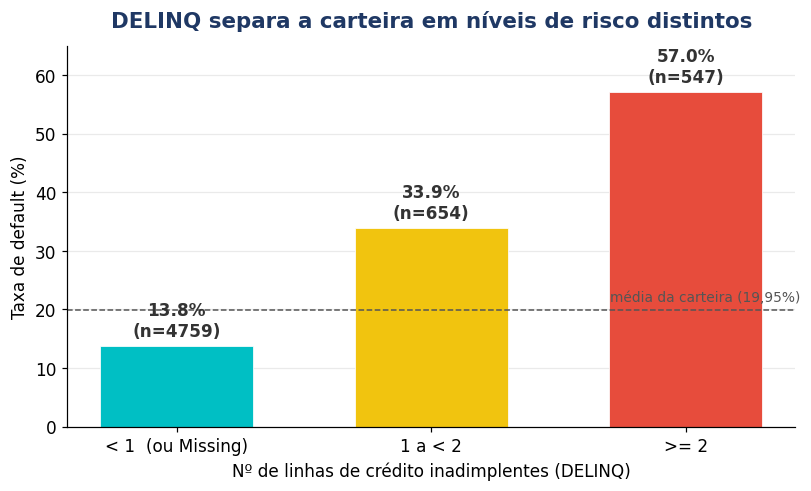

In [24]:
cores_seg = ['#00BFC4', '#F1C40F', '#E74C3C']   # baixo, médio, alto risco

fig, ax = plt.subplots(figsize=(7.5, 4.6))
barras = ax.bar(seg['grupo_delinq'], seg['tx_default'],
                color=cores_seg, edgecolor='white', linewidth=0.5, width=0.6)

for b, txr, cnt in zip(barras, seg['tx_default'], seg['Count']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{txr:.1f}%\n(n={cnt})', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#333')

ax.axhline(19.95, color='#555', ls='--', lw=1)
ax.text(2.45, 20.8, 'média da carteira (19,95%)', color='#555',
        ha='right', va='bottom', fontsize=9)

ax.set_title('DELINQ separa a carteira em níveis de risco distintos',
             fontsize=14, fontweight='bold', color=AZUL, pad=12)
ax.set_ylabel('Taxa de default (%)')
ax.set_xlabel('Nº de linhas de crédito inadimplentes (DELINQ)')
ax.set_ylim(0, 65)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#EAEAEA', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
# plt.savefig('yochi_delinq_segmentos.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [25]:
from matplotlib.patches import FancyBboxPatch, FancyArrow
from sklearn.tree import DecisionTreeClassifier

def cortes_automaticos(df, var, target='BAD', n_grupos=3):
    """Aprende os pontos de corte com uma árvore (data-driven)."""
    X = df[[var]].values
    y = df[target].values
    tree = DecisionTreeClassifier(max_leaf_nodes=n_grupos, random_state=42).fit(X, y)
    t = tree.tree_
    thr = sorted(t.threshold[i] for i in range(t.node_count) if t.children_left[i] != -1)
    return [round(c, 4) for c in thr]

def arvore_segmentacao(df, var, cortes, target='BAD', titulo=None,
                       cores=None, rotulos=None):
    """Desenha uma árvore estilo SAS. Só 'cortes' é entrada; o resto vem do dado."""
    bins = [-np.inf, *cortes, np.inf]
    grupo = pd.cut(df[var], bins=bins, right=False)
    seg = df.groupby(grupo, observed=True)[target].agg(n='count', bad='mean')
    seg = seg.sort_index()
    k = len(seg)

    # rótulos dos ramos, gerados a partir dos cortes
    if rotulos is None:
        rotulos = []
        limites = [-np.inf, *cortes, np.inf]
        for i in range(k):
            lo, hi = limites[i], limites[i+1]
            if lo == -np.inf:   rotulos.append(f'< {hi:g}  (ou Missing)')
            elif hi == np.inf:  rotulos.append(f'≥ {lo:g}')
            else:               rotulos.append(f'≥ {lo:g}  e  < {hi:g}')

    if cores is None:
        base = ['#5B9BD5', '#F1C40F', '#E74C3C', '#8E44AD', '#27AE60']
        cores = [base[i % len(base)] for i in range(k)]
    fills = ['#DCE6F1', '#FFF7CC', '#FADBD8', '#EBDEF0', '#D5F5E3']

    tot, raiz_bad = len(df), df[target].mean()
    AZUL = '#1F3864'

    def caixa(ax, x, y, bad, n, fc, w=2.1, h=1.15):
        ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
            boxstyle='round,pad=0.02,rounding_size=0.05', fc=fc, ec='#7f7f7f', lw=1.2))
        ax.text(x, y+0.28, f'1:  {bad*100:5.2f}%', ha='center', va='center',
                fontsize=10.5, family='monospace', fontweight='bold')
        ax.text(x, y+0.02, f'0:  {(1-bad)*100:5.2f}%', ha='center', va='center',
                fontsize=10.5, family='monospace')
        ax.text(x, y-0.28, f'Count: {n:>5}', ha='center', va='center',
                fontsize=10.5, family='monospace')

    fig, ax = plt.subplots(figsize=(3.0*k, 6))
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')

    rx, ry = 5, 8.4
    caixa(ax, rx, ry, raiz_bad, tot, '#BFD3E6')
    ax.text(rx, ry-0.85, var, ha='center', va='center',
            fontsize=11, fontweight='bold', color=AZUL)

    xs = np.linspace(1.5, 8.5, k)     # posições dos filhos, distribuídas
    cy = 4.2
    for x, (idx, r), brlab, ac, fc in zip(xs, seg.iterrows(), rotulos, cores, fills):
        ax.plot([rx, rx], [ry-0.6, 6.2], color='#404040', lw=2)
        ax.plot([x, x], [6.2, cy+0.62], color='#404040', lw=2)
        ax.plot([min(rx, x), max(rx, x)], [6.2, 6.2], color='#404040', lw=2)
        ax.text(x, 5.75, brlab, ha='center', va='center', fontsize=9)
        caixa(ax, x, cy, r['bad'], int(r['n']), fc)
        ax.add_patch(FancyArrow(x, cy-0.75, 0, -0.9, width=0.28,
                                head_width=0.55, head_length=0.4,
                                fc=ac, ec=ac, length_includes_head=True))
        ax.text(x, 1.95, f'≈ {r["n"]/tot*100:.0f}%', ha='center', va='center',
                fontsize=12, fontweight='bold', color='#333')

    ax.set_title(titulo or f'{var} segmenta a carteira em {k} perfis de risco',
                 fontsize=14, fontweight='bold', color=AZUL, y=0.98)
    plt.tight_layout()
    return fig, ax

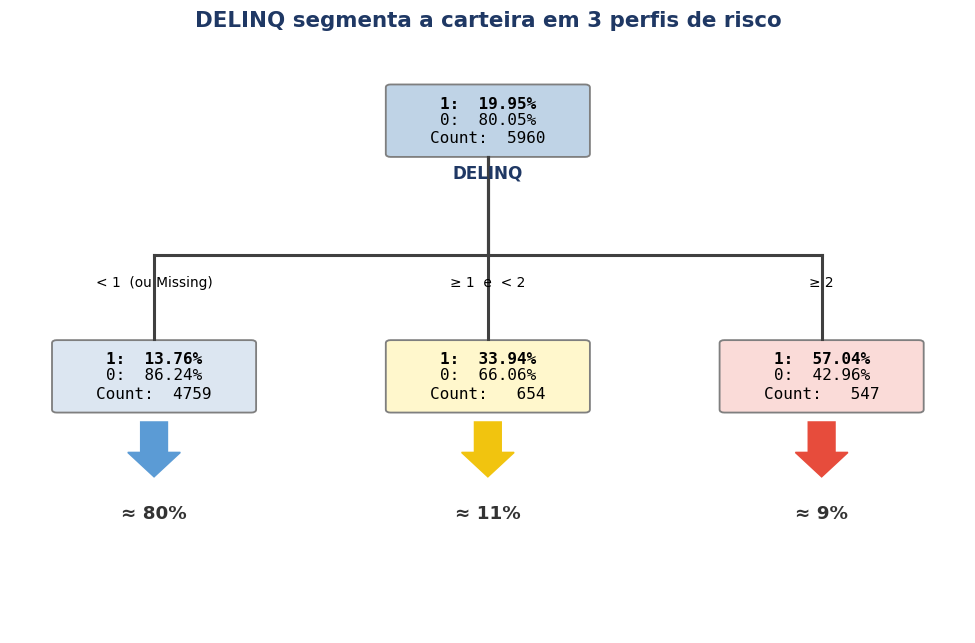

In [26]:
# Opção A: replicar o slide (cortes fixados em 1 e 2)
arvore_segmentacao(df_t, 'DELINQ', cortes=[1, 2])
plt.show()

# Opção B: cortes 100% data-driven (a árvore escolhe -> 0,5 e 4,5)
# arvore_segmentacao(df_t, 'DELINQ', cortes=cortes_automaticos(df_t, 'DELINQ'))
# plt.show()

A DELINQ separa a carteira em três perfis com risco bem diferente.

O primeiro grupo tem 80% dos clientes (DELINQ < 1) e 13,76% de inadimplência, abaixo da média.

O segundo reúne 11% da carteira (DELINQ entre 1 e 2) e sobe para 33,94% de inadimplência.

O terceiro concentra 9% dos clientes (DELINQ ≥ 2) e chega a 57,04%, quase três vezes a média da carteira.

O risco cresce de forma acentuada conforme aumenta o número de linhas em atraso. Isso mostra que uma única variável já é capaz de identificar públicos muito distintos e evidencia que o processo atual vinha aprovando crédito para perfis de alto risco.

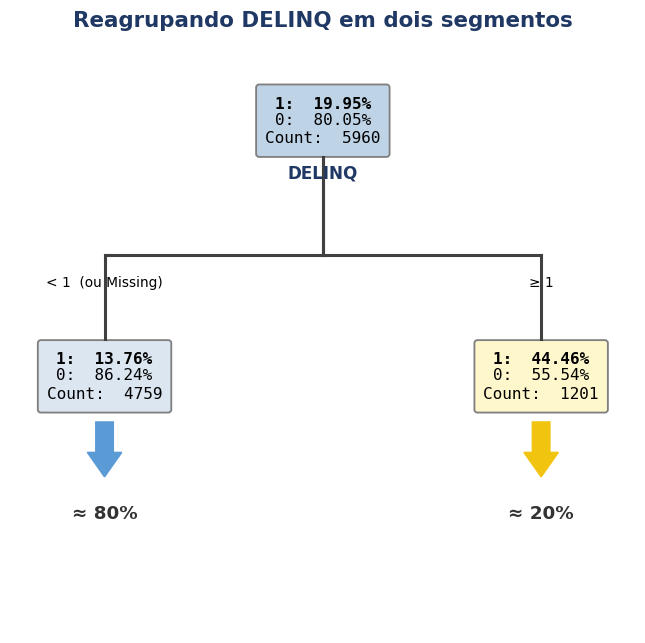

In [27]:
arvore_segmentacao(
    df_t, 'DELINQ', cortes=[1],
    titulo='Reagrupando DELINQ em dois segmentos'
)
# plt.savefig('yochi_arvore_delinq_2grupos.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

Reagrupando a DELINQ em dois grupos, a carteira se divide em dois públicos bem distintos.

O primeiro reúne 80% dos clientes (DELINQ < 1) e tem taxa de inadimplência de 13,76%, abaixo da média.

O segundo concentra os 20% restantes (DELINQ ≥ 1) e chega a 44,46% de inadimplência, mais que o dobro da média da carteira.

Basta o cliente ter uma linha de crédito em atraso para o risco de default mais que dobrar. Esse corte simples já entrega uma regra de decisão clara para orientar a aprovação de crédito.

In [29]:
# segmento pela DELINQ
df_t['Seg'] = np.where(df_t['DELINQ'] < 1, 'Clear', 'Dirty')

grand_total = df_t['LOAN'].sum()

# soma de LOAN por (Seg, BAD)
tab = (df_t.groupby(['Seg', 'BAD'])['LOAN'].sum()
            .reset_index(name='Loan'))

# Percentual = participação do segmento dentro de cada BAD
tab['Percentual'] = tab.groupby('BAD')['Loan'].transform(lambda s: s / s.sum())

# Perc_total = participação do segmento no total geral
seg_share = df_t.groupby('Seg')['LOAN'].sum() / grand_total
tab['Perc_total'] = tab['Seg'].map(seg_share)

# linhas de total por BAD
tot_bad = (df_t.groupby('BAD')['LOAN'].sum()
                .reset_index(name='Loan')
                .assign(Seg='Total', Percentual=1.0,
                        Perc_total=lambda d: d['Loan'] / grand_total))

# linha do total geral
tot_geral = pd.DataFrame({'Seg': ['Total'], 'BAD': ['Total'],
                          'Loan': [grand_total], 'Percentual': [np.nan],
                          'Perc_total': [np.nan]})

tabela_exp = pd.concat([tab, tot_bad, tot_geral], ignore_index=True)[
    ['Seg', 'BAD', 'Loan', 'Percentual', 'Perc_total']]

(tabela_exp.style
   .format({'Loan': 'R$ {:,.2f}',
            'Percentual': lambda v: '' if pd.isna(v) else f'{v*100:.0f}%',
            'Perc_total': lambda v: '' if pd.isna(v) else f'{v*100:.0f}%'})
   .hide(axis='index')
   .set_caption('Exposição de crédito por segmento e status'))

Seg,BAD,Loan,Percentual,Perc_total
Clear,0,"R$ 78,732,900.00",87%,81%
Clear,1,"R$ 10,643,500.00",53%,81%
Dirty,0,"R$ 12,050,200.00",13%,19%
Dirty,1,"R$ 9,476,900.00",47%,19%
Total,0,"R$ 90,783,100.00",100%,82%
Total,1,"R$ 20,120,400.00",100%,18%
Total,Total,"R$ 110,903,500.00",,


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">4. ANÁLISE DE APROVAÇÃO</h1>
<p style="font-size:15px;line-height:1.6;color:#2D2A32;">

In [31]:
# 1) apenas população Clean (DELINQ < 1)
clean = df_t[df_t['Seg'] == 'Clear'].copy()
y = clean['BAD']

# DELINQ é constante (=0) dentro da Clean, então sai; grupo_delinq/Seg são auxiliares
X = clean.drop(columns=[c for c in ['BAD', 'Seg', 'DELINQ', 'grupo_delinq']
                        if c in clean.columns])

num = [c for c in X.columns if X[c].dtype.kind in 'biufc']
cat = [c for c in X.columns if c not in num]

pre  = ColumnTransformer([('num', StandardScaler(), num),
                          ('cat', OneHotEncoder(handle_unknown='ignore'), cat)])
pipe = Pipeline([('pre', pre),
                 ('lr', LogisticRegression(max_iter=1000))])

# split só para medir a discriminação de forma honesta
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
pipe.fit(Xtr, ytr)
auc = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])
print(f'AUC (teste) = {auc:.3f}')

# score de risco 0-100 para toda a Clean (quanto maior, maior o risco)
clean['score'] = pipe.predict_proba(X)[:, 1] * 100

AUC (teste) = 0.780


In [32]:
bandas = np.arange(0, 100, 5)
clean['banda'] = np.clip((clean['score'] // 5) * 5, 0, 95).astype(int)

corte = clean.groupby('banda')['BAD'].agg(n='count', bad='mean').reindex(bandas, fill_value=0)
corte['pop_acum'] = corte['n'].cumsum() / corte['n'].sum() * 100
corte['bad_acum'] = (clean.groupby('banda')['BAD'].sum().reindex(bandas, fill_value=0).cumsum()
                     / corte['n'].cumsum().replace(0, np.nan)) * 100
corte['bad'] = corte['bad'] * 100

corte.round(1)

,n,bad,pop_acum,bad_acum
banda,,,,
0,1652,5.0,34.7,5.0
5,1343,5.5,62.9,5.2
10,616,8.4,75.9,5.8
15,267,12.0,81.5,6.2
20,116,19.8,83.9,6.6
25,98,29.6,86.0,7.2
30,78,32.1,87.6,7.6
35,102,38.2,89.8,8.4
40,99,37.4,91.8,9.0


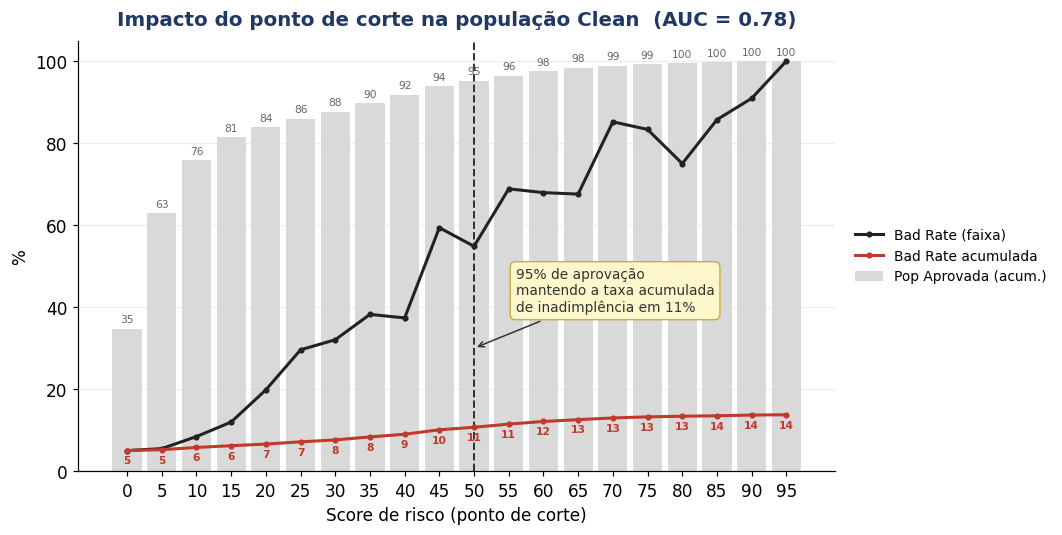

In [35]:
CORTE_REC = 50   # ponto de corte recomendado

fig, ax = plt.subplots(figsize=(9.8, 5))

ax.bar(bandas, corte['pop_acum'], width=4.2, color='#D9D9D9',
       label='Pop Aprovada (acum.)', zorder=1)
ax.plot(bandas, corte['bad'], color='#222', lw=2, marker='o', ms=3,
        label='Bad Rate (faixa)', zorder=3)
ax.plot(bandas, corte['bad_acum'], color='#C0392B', lw=2, marker='o', ms=3,
        label='Bad Rate acumulada', zorder=3)

for xb, v in zip(bandas, corte['pop_acum']):
    ax.text(xb, v + 1.5, f'{v:.0f}', ha='center', fontsize=7, color='#666')
for xb, v in zip(bandas, corte['bad_acum']):
    ax.text(xb, v - 3.2, f'{v:.0f}', ha='center', fontsize=7,
            color='#C0392B', fontweight='bold')

# --- recomendação de corte ---
pop_rec = corte.loc[CORTE_REC, 'pop_acum']
bad_rec = corte.loc[CORTE_REC, 'bad_acum']

ax.axvline(CORTE_REC, color='#333', ls='--', lw=1.3, zorder=2)
ax.annotate(
    f'{pop_rec:.0f}% de aprovação\nmantendo a taxa acumulada\nde inadimplência em {bad_rec:.0f}%',
    xy=(CORTE_REC, 30), xytext=(CORTE_REC + 6, 44),
    fontsize=9, color='#333', ha='left', va='center',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF7CC', ec='#C9A227', lw=0.8),
    arrowprops=dict(arrowstyle='->', color='#333', lw=1))

ax.set_title(f'Impacto do ponto de corte na população Clean  (AUC = {auc:.2f})',
             fontsize=13, fontweight='bold', color=AZUL, pad=10)
ax.set_xlabel('Score de risco (ponto de corte)')
ax.set_ylabel('%')
ax.set_ylim(0, 105)
ax.set_xticks(bandas)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#EEE')
ax.set_axisbelow(True)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=9)

plt.tight_layout()
# plt.savefig('yochi_ponto_corte.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

Olhando apenas para a população Clean, o ponto de corte do score define quanto da carteira é aprovada e qual a inadimplência resultante.

Conforme o corte avança para scores mais altos, aprova-se mais clientes, mas entram perfis de risco crescente e a inadimplência acumulada sobe.

O corte no score 50 aprova 95% da população Clean mantendo a inadimplência acumulada em 11%, abaixo dos 13,76% do segmento sem nenhum critério.

Esse corte equilibra volume de aprovação e risco, e serve como regra objetiva para alinhar a concessão de crédito à política da empresa.

<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">5. RESULTADO FINANCEIRO</h1>
<p style="font-size:15px;line-height:1.6;color:#2D2A32;">

In [36]:
CORTE = 50          # ponto de corte do score (mesmo do gráfico)
CDI   = 0.120272    # custo de oportunidade do cliente bom negado (CDI 12 meses)

# garante o score em toda a base (Clean scoreada; Dirty fica sem score = rejeitado)
df_t['score'] = np.nan
df_t.loc[clean.index, 'score'] = pipe.predict_proba(X)[:, 1] * 100

# Decisão: aprova Clean com score <= corte; rejeita Dirty e Clean acima do corte
df_t['Aprovado'] = np.where((df_t['Seg'] == 'Clear') & (df_t['score'] <= CORTE), 1, 0)

In [37]:
grand_total = df_t['LOAN'].sum()
antes = (df_t.groupby('BAD')['LOAN'].sum().reset_index(name='Loan'))
antes['Percentual'] = antes['Loan'] / grand_total
antes = pd.concat([antes,
    pd.DataFrame({'BAD': ['Total'], 'Loan': [grand_total], 'Percentual': [np.nan]})],
    ignore_index=True)

(antes.style
   .format({'Loan': 'R$ {:,.2f}',
            'Percentual': lambda v: '' if pd.isna(v) else f'{v*100:.0f}%'})
   .hide(axis='index')
   .set_caption('ANTES — perda aprovando toda a carteira'))

BAD,Loan,Percentual
0,"R$ 90,783,100.00",82%
1,"R$ 20,120,400.00",18%
Total,"R$ 110,903,500.00",


In [38]:
g = df_t.groupby(['Aprovado', 'BAD'])['LOAN'].sum()
def loan(a, b): return g.get((a, b), 0.0)

depois = pd.DataFrame([
    ['0 (negado)',   '0 (bom)', loan(0, 0) * CDI, 0.0],          # bom negado -> custo CDI
    ['0 (negado)',   '1 (mau)', 0.0,              loan(0, 1)],   # mau negado -> perda evitada
    ['1 (aprovado)', '0 (bom)', 0.0,              0.0],          # bom aprovado -> ok
    ['1 (aprovado)', '1 (mau)', loan(1, 1),       0.0],          # mau aprovado -> perda 100%
], columns=['Aprovado', 'BAD', 'Perda modelo', 'Perda Evitada'])

depois = pd.concat([depois,
    pd.DataFrame([['TOTAL', '', depois['Perda modelo'].sum(),
                   depois['Perda Evitada'].sum()]], columns=depois.columns)],
    ignore_index=True)

(depois.style
   .format({'Perda modelo': 'R$ {:,.2f}', 'Perda Evitada': 'R$ {:,.2f}'})
   .hide(axis='index')
   .set_caption('DEPOIS — resultado com o modelo'))

Aprovado,BAD,Perda modelo,Perda Evitada
0 (negado),0 (bom),"R$ 1,596,971.62",R$ 0.00
0 (negado),1 (mau),R$ 0.00,"R$ 11,913,000.00"
1 (aprovado),0 (bom),R$ 0.00,R$ 0.00
1 (aprovado),1 (mau),"R$ 8,207,400.00",R$ 0.00
TOTAL,,"R$ 9,804,371.62","R$ 11,913,000.00"


In [39]:
perda_antes  = df_t.loc[df_t['BAD'] == 1, 'LOAN'].sum()          # aprova todos
perda_modelo = depois.loc[depois['Aprovado'] == 'TOTAL', 'Perda modelo'].iloc[0]
ganho        = perda_antes - perda_modelo

exp = pd.DataFrame({
    'Cenário': ['Modelo', 'Sem modelo'],
    'Exposição Total': [df_t.loc[df_t['Aprovado'] == 1, 'LOAN'].sum(), grand_total],
    '#Clientes': [int((df_t['Aprovado'] == 1).sum()), len(df_t)]})
reducao = grand_total - exp['Exposição Total'].iloc[0]

print(f'Perda sem modelo : R$ {perda_antes:,.2f}')
print(f'Perda com modelo : R$ {perda_modelo:,.2f}')
print(f'GANHO FINANCEIRO : R$ {ganho:,.2f}')
print(f'Redução de exposição: R$ {reducao:,.2f} ({reducao/grand_total*100:.1f}%)')

(exp.style.format({'Exposição Total': 'R$ {:,.0f}', '#Clientes': '{:,.0f}'})
    .hide(axis='index').set_caption('Exposição: com x sem modelo'))

Perda sem modelo : R$ 20,120,400.00
Perda com modelo : R$ 9,804,371.62
GANHO FINANCEIRO : R$ 10,316,028.38
Redução de exposição: R$ 25,191,000.00 (22.7%)


Cenário,Exposição Total,#Clientes
Modelo,"R$ 85,712,500","4,467"
Sem modelo,"R$ 110,903,500","5,960"


<h1 style="font-size: 30px; font-weight: 900; letter-spacing: 0px;">6. CONCLUSÃO</h1>
<p style="font-size:15px;line-height:1.6;color:#2D2A32;">

O processo de aprovação atual não usa embasamento estatístico e gera perda de 20,1 milhões de reais, com inadimplência de 19,95% concentrada em clientes com histórico de dívida e atraso.

A análise mostrou que endividamento (DEBTINC) e linhas em atraso (DELINQ) são os principais preditores de default. Só a DELINQ já separa a carteira em públicos com risco de 13% a 57%.

Com a segmentação por DELINQ e um score de crédito na população Clean, é possível definir um ponto de corte que aprova 95% desse público mantendo a inadimplência acumulada em 11%.

Aplicando o modelo, a perda cai de 20,1 milhões para cerca de 10 milhões de reais, um ganho financeiro de aproximadamente 10 milhões. A exposição total recua de 110,9 milhões para 86 milhões de reais ao evitar crédito para os perfis de maior risco.

Recomenda-se adotar o modelo como apoio à decisão de crédito, aprovando clientes pela regra de segmento e score, e revisar o ponto de corte periodicamente conforme a política de risco da empresa.